Phần 1: Làm sạch dữ liệu & Tạo Feature

Data cleaned successfully! File saved at: /content/HMU_Hospital_Cleaned.csv
Remaining valid reviews: 1174

[Visualization] - Rating Distribution:


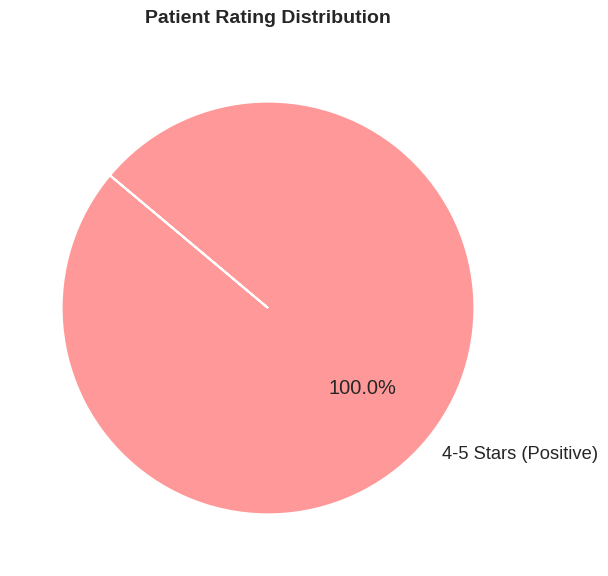

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk", font_scale=0.8)

# 1. Load data from Google Colab (Excel format)
file_path = "/content/DataGGmapReviews-BV_Đại_học_Y_Hà_Nội.xlsx"
df_raw = pd.read_excel(file_path)

# 2. Remove duplicates and empty reviews
df_clean = df_raw.dropna(subset=['review_text']).copy()
df_clean = df_clean.drop_duplicates(subset=['review_id'])

# 3. Vietnamese Normalization Function
def clean_and_normalize_vi(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces

    # Medical abbreviations mapping (Vietnamese context)
    text = re.sub(r'\b(bs|bsi|bác sỹ)\b', 'bác sĩ', text)
    text = re.sub(r'\bnv\b', 'nhân viên', text)
    text = re.sub(r'\bbv\b', 'bệnh viện', text)
    text = re.sub(r'\b(ko|khg|k)\b', 'không', text)
    text = re.sub(r'\b(dc|đc)\b', 'được', text)
    text = re.sub(r'\b(đợi lâu|đợi quá lâu)\b', 'chờ lâu', text)

    return text

df_clean['review_text_norm'] = df_clean['review_text'].apply(clean_and_normalize_vi)

# 4. Feature Engineering
# Review length (word count)
df_clean['review_length'] = df_clean['review_text_norm'].apply(lambda x: len(x.split()))

# Rating segmentation
def get_rating_group(rating):
    if rating <= 2: return '1-2 Stars (Negative)'
    elif rating == 3: return '3 Stars (Neutral)'
    else: return '4-5 Stars (Positive)'

df_clean['rating_group'] = df_clean['rating'].apply(get_rating_group)
df_clean['has_owner_response'] = df_clean['owner_answer'].notnull().astype(int)

# Extract Time features
df_clean['review_datetime'] = pd.to_datetime(df_clean['review_datetime_utc'])
df_clean['year_month'] = df_clean['review_datetime'].dt.to_period('M').astype(str)
df_clean['quarter'] = df_clean['review_datetime'].dt.quarter

output_path = "/content/HMU_Hospital_Cleaned.csv"
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Data cleaned successfully! File saved at: {output_path}")
print(f"Remaining valid reviews: {len(df_clean)}")

# --- VISUALIZATION: RATING DISTRIBUTION ---
print("\n[Visualization] - Rating Distribution:")
plt.figure(figsize=(8, 6))
rating_counts = df_clean['rating_group'].value_counts().sort_index()

colors = ['#ff9999', '#ffcc99', '#66b3ff']
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
        startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})

plt.title('Patient Rating Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


Phần 2: Dịch sang Tiếng Anh & Xóa Stopwords (English-First)

In [ ]:
!pip install deep-translator
from deep_translator import GoogleTranslator
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# 1. Initialize translator
translator = GoogleTranslator(source='vi', target='en')

def translate_to_english(text):
    try:
        # Truncate if it exceeds translator limits
        return translator.translate(text[:4999])
    except:
        return ""

# 2. Translate all reviews
print("Translating from Vietnamese to English... (This may take a few minutes)")
df_clean['review_text_en'] = df_clean['review_text_norm'].apply(translate_to_english)

# 3. Remove English Stopwords
# Retain negation words for accurate Sentiment Analysis
stop_words = set(stopwords.words('english'))
words_to_keep = {'not', 'no', 'never', 'nor', 'none', 'cannot', 'isn', "isn't"}
custom_stopwords = stop_words - words_to_keep

def remove_en_stopwords(text):
    words = str(text).split()
    clean_words = [w for w in words if w.lower() not in custom_stopwords]
    return " ".join(clean_words)

df_clean['review_text_en_clean'] = df_clean['review_text_en'].apply(remove_en_stopwords)

print("Translation and Stopwords removal completed!")
print(df_clean[['review_text_norm', 'review_text_en_clean']].head(3))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Translating from Vietnamese to English... (This may take a few minutes)


Phần 3: Trích xuất Issue bằng Cosine Similarity

In [ ]:
!pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
import torch

# Load standard English Embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 1. Define Issue Taxonomy & Seed Sentences
issue_seeds = {
    'Overcrowding & Waiting Time': [
        "the waiting time is too long", "I had to wait for hours", "slow process",
        "queue is too long", "the hospital is overcrowded", "too many people",
        "takes a very long time", "very crowded", "takes forever to see a doctor",
        "overloaded with patients", "exhausting wait"
    ],
    'Staff Attitude': ["staff was rude", "unfriendly nurses", "bad attitude", "arrogant doctor", "poor customer service"],
    'Cleanliness': ["the hospital is dirty", "smells bad", "unclean bathroom", "poor hygiene"],
    'Procedure & Guidance': ["complex procedure", "no clear instructions", "confusing process", "hard to navigate"],
    'Parking & Security': ["no parking space", "security guard was rude", "hard to park"],
    'Cost & Price': ["too expensive", "hidden fees", "high cost", "pricey"],

    'Doctor Expertise': ["great doctor", "highly skilled", "professional doctor", "good treatment", "caring doctor"],
    'Facilities': ["modern facilities", "advanced equipment", "clean hospital", "spacious"],
    'General Compliment': ["great experience", "good hospital", "highly recommended", "excellent service"]
}

# 2. Vectorize seed sentences
seed_embeddings = {issue: model.encode(sentences, convert_to_tensor=True)
                   for issue, sentences in issue_seeds.items()}

# 3. Cosine Similarity matching function
def extract_issue(review_text):
    if not isinstance(review_text, str) or review_text == "":
        return "Other"

    review_emb = model.encode(review_text, convert_to_tensor=True)
    best_issue = "Other"
    highest_score = 0.0
    THRESHOLD = 0.35

    for issue, seeds_emb in seed_embeddings.items():
        cosine_scores = util.cos_sim(review_emb, seeds_emb)
        max_score_for_issue = torch.max(cosine_scores).item()

        if max_score_for_issue > highest_score and max_score_for_issue > THRESHOLD:
            highest_score = max_score_for_issue
            best_issue = issue

    return best_issue

# Apply classification
df_clean['assigned_issue'] = df_clean['review_text_en_clean'].apply(extract_issue)

# --- VISUALIZATION: ISSUE FREQUENCY ---
print("\n[Visualization] - Issue Frequency:")
plt.figure(figsize=(12, 7))

issue_freq = df_clean['assigned_issue'].value_counts().sort_values(ascending=True)
ax = issue_freq.plot(kind='barh', color='#4C72B0', width=0.7)

for i, v in enumerate(issue_freq):
    ax.text(v + 3, i - 0.1, str(v), color='black', fontweight='bold')

plt.title('Frequency of Identified Issues', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Operational Issues', fontsize=12)
plt.tight_layout()
plt.show()

Phần 4: Chạy BERTopic để tìm Topic ẩn

In [ ]:
# 1. Install BERTopic library directly on Colab
!pip install bertopic

# 2. Import after installation
from bertopic import BERTopic

# 3. Prepare the text corpus (English)
docs = df_clean[df_clean['review_text_en_clean'].str.strip() != ""]['review_text_en_clean'].tolist()

# 4. Train the BERTopic model
print("Training BERTopic model... (This may take a moment to download the model and train)")
topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics, probabilities = topic_model.fit_transform(docs)

# 5. View discovered topics (Tabular format)
freq = topic_model.get_topic_info()
print("\n--- TOP 10 DISCOVERED TOPICS ---")
print(freq.head(10))

# ==========================================
# 6. OUTPUT VISUALIZATION
# ==========================================
print("\nGenerating visualizations...")

# Chart 1: Barchart - Shows the most important keywords defining each Topic
# Extremely useful for your Report to explain the core meaning of each cluster (e.g., Topic 0, Topic 1)
fig_barchart = topic_model.visualize_barchart(top_n_topics=8, n_words=8, title="Top Words per Topic")
fig_barchart.show()

# Chart 2: Intertopic Distance Map
# Draws topics as circles; the larger the circle, the more frequent the topic.
# Circles close to each other indicate semantic similarity.
fig_distance = topic_model.visualize_topics(title="Intertopic Distance Map")
fig_distance.show()

# Chart 3: Heatmap - Shows the similarity/correlation between Topics
# Darker colors mean those two topic clusters frequently appear together or have similar meanings.
fig_heatmap = topic_model.visualize_heatmap(n_topics=10, width=800, height=800, title="Topic Similarity Heatmap")
fig_heatmap.show()


Phần 5: Sentiment Analysis

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Download VADER lexicon
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# 2. Sentiment calculation function
def get_sentiment_score(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return sia.polarity_scores(text)['compound']

# 3. Calculate scores
print("Calculating Sentiment Scores...")
df_clean['sentiment_score'] = df_clean['review_text_en_clean'].apply(get_sentiment_score)

# 4. Assign categorical labels
def categorize_sentiment(score):
    if score <= -0.05: return 'Negative'
    elif score >= 0.05: return 'Positive'
    else: return 'Neutral'

df_clean['sentiment_label'] = df_clean['sentiment_score'].apply(categorize_sentiment)
print("Sentiment analysis completed!")

# --- VISUALIZATION: SENTIMENT BY ISSUE ---
print("\n[Visualization] - Sentiment Proportion by Issue:")
plt.figure(figsize=(14, 8))

sentiment_crosstab = pd.crosstab(df_clean['assigned_issue'], df_clean['sentiment_label'], normalize='index') * 100

if 'Negative' in sentiment_crosstab.columns:
    sentiment_crosstab = sentiment_crosstab.sort_values(by='Negative', ascending=True)

colors_dict = {'Negative': '#d65f5f', 'Neutral': '#b8b8b8', 'Positive': '#5fba7d'}
cols_present = [c for c in ['Negative', 'Neutral', 'Positive'] if c in sentiment_crosstab.columns]
plot_colors = [colors_dict[c] for c in cols_present]

ax = sentiment_crosstab[cols_present].plot(kind='barh', stacked=True, color=plot_colors, figsize=(14, 8), width=0.75)

plt.title('Sentiment Proportion by Operational Issue', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Operational Issues', fontsize=12)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

Phần 6: Tính Priority Score

In [ ]:
import pandas as pd

# 1. Statistical Aggregation
issue_stats = df_clean.groupby('assigned_issue').agg(
    Frequency=('review_id', 'count'),
    Negativity_Count=('sentiment_label', lambda x: (x == 'Negative').sum())
).reset_index()

issue_stats['Negativity_Rate'] = issue_stats['Negativity_Count'] / issue_stats['Frequency']

# 2. Define Business Impact Weights
impact_weights = {
    'Overcrowding & Waiting Time': 4,
    'Staff Attitude': 3,
    'Cleanliness': 2,
    'Procedure & Guidance': 2,
    'Parking & Security': 1,
    'Cost & Price': 1,
    'Doctor Expertise': 1,
    'Facilities': 1,
    'General Compliment': 1,
    'Other': 1
}
issue_stats['Business_Impact'] = issue_stats['assigned_issue'].map(impact_weights).fillna(1)

# 3. Calculate Priority Score
issue_stats['Priority_Score'] = round(
    issue_stats['Frequency'] * issue_stats['Negativity_Rate'] * issue_stats['Business_Impact'], 2
)

# 4. Sort and display
issue_stats = issue_stats.sort_values(by='Priority_Score', ascending=False).reset_index(drop=True)

print("=== PRIORITY SCORE RANKING ===")
print(issue_stats[['assigned_issue', 'Frequency', 'Negativity_Rate', 'Business_Impact', 'Priority_Score']])

# Export final dataset
output_final = "/content/HMU_Hospital_Final_Result.csv"
df_clean.to_csv(output_final, index=False, encoding='utf-8-sig')

# --- VISUALIZATION: PRIORITY SCORE ---
print("\n[Visualization] - Priority Score Ranking:")
plt.figure(figsize=(12, 7))

issue_stats_sorted = issue_stats.sort_values(by='Priority_Score', ascending=True)
bars = plt.barh(issue_stats_sorted['assigned_issue'], issue_stats_sorted['Priority_Score'], color='#C44E52')

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2 - 0.1,
             f"{bar.get_width():.1f}",
             va='center', color='black', fontweight='bold')

plt.title('Operational Issues Prioritization (Priority Score)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Calculated Priority Score', fontsize=12)
plt.ylabel('Operational Issues', fontsize=12)
plt.tight_layout()
plt.show()